In [2]:
%cd ..
%ls

/Users/andrewmcknight/code/ceol-gpt
ATTRIBUTION.md    SETUP.md          docs/             requirements.txt
CLAUDE.md         configs/          models/           src/
README.md         data/             notebooks/        videos/


In [3]:
import json
from collections import Counter
import matplotlib.pyplot as plt

from src.tokenizer import ABCTokenizer, tokenize_abc, _first_note_from_chord

with open('data/tunes.json') as f:
    tunes = json.load(f)

print(f'Loaded {len(tunes):,} tunes')

Loaded 54,246 tunes


## Build vocabulary

In [6]:
tokenizer = ABCTokenizer.from_tunes(tunes, min_freq=2)
vocab = tokenizer.vocab.token_to_id

In [8]:
vocab

{'<PAD>': 0,
 '<BOS>': 1,
 '<EOS>': 2,
 '<UNK>': 3,
 '<TYPE:barndance>': 4,
 '<TYPE:hornpipe>': 5,
 '<TYPE:jig>': 6,
 '<TYPE:march>': 7,
 '<TYPE:mazurka>': 8,
 '<TYPE:polka>': 9,
 '<TYPE:reel>': 10,
 '<TYPE:slide>': 11,
 '<TYPE:slip jig>': 12,
 '<TYPE:strathspey>': 13,
 '<TYPE:three-two>': 14,
 '<TYPE:waltz>': 15,
 '<KEY:Adorian>': 16,
 '<KEY:Amajor>': 17,
 '<KEY:Aminor>': 18,
 '<KEY:Amixolydian>': 19,
 '<KEY:Bdorian>': 20,
 '<KEY:Bminor>': 21,
 '<KEY:Bmixolydian>': 22,
 '<KEY:Cdorian>': 23,
 '<KEY:Cmajor>': 24,
 '<KEY:Ddorian>': 25,
 '<KEY:Dmajor>': 26,
 '<KEY:Dminor>': 27,
 '<KEY:Dmixolydian>': 28,
 '<KEY:Edorian>': 29,
 '<KEY:Emajor>': 30,
 '<KEY:Eminor>': 31,
 '<KEY:Emixolydian>': 32,
 '<KEY:Fdorian>': 33,
 '<KEY:Fmajor>': 34,
 '<KEY:Gdorian>': 35,
 '<KEY:Gmajor>': 36,
 '<KEY:Gminor>': 37,
 '<KEY:Gmixolydian>': 38,
 '<METER:12/8>': 39,
 '<METER:2/4>': 40,
 '<METER:3/2>': 41,
 '<METER:3/4>': 42,
 '<METER:4/4>': 43,
 '<METER:6/8>': 44,
 '<METER:9/8>': 45,
 '(1': 46,
 '(2': 47,
 '(3':

In [11]:
[tok for tok in vocab.keys() if tok.startswith('<KEY:')]

['<KEY:Adorian>',
 '<KEY:Amajor>',
 '<KEY:Aminor>',
 '<KEY:Amixolydian>',
 '<KEY:Bdorian>',
 '<KEY:Bminor>',
 '<KEY:Bmixolydian>',
 '<KEY:Cdorian>',
 '<KEY:Cmajor>',
 '<KEY:Ddorian>',
 '<KEY:Dmajor>',
 '<KEY:Dminor>',
 '<KEY:Dmixolydian>',
 '<KEY:Edorian>',
 '<KEY:Emajor>',
 '<KEY:Eminor>',
 '<KEY:Emixolydian>',
 '<KEY:Fdorian>',
 '<KEY:Fmajor>',
 '<KEY:Gdorian>',
 '<KEY:Gmajor>',
 '<KEY:Gminor>',
 '<KEY:Gmixolydian>']

In [12]:
print(f'Vocabulary size: {len(tokenizer):,}')

Vocabulary size: 939


## Token frequency distribution

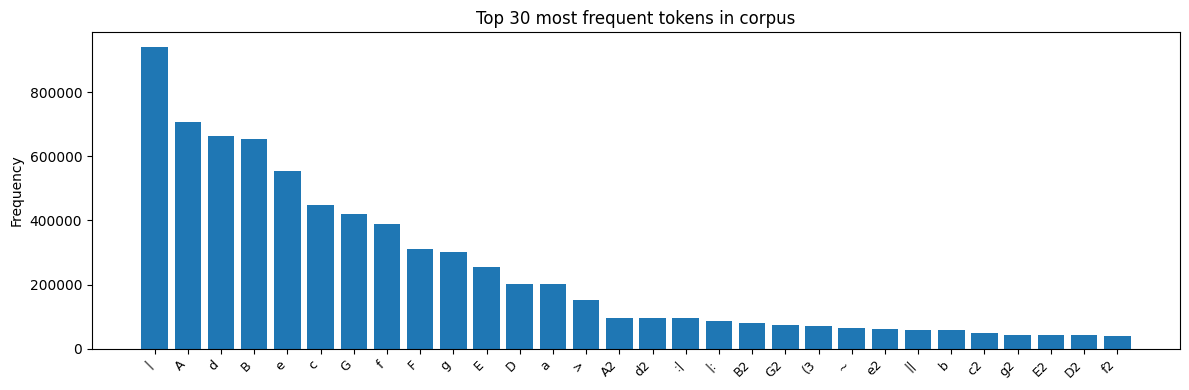

Total tokens in corpus: 8,107,210


In [19]:
counter = Counter()
for tune in tunes:
    counter.update(tokenize_abc(tune['abc']))

most_common = counter.most_common(30)
tokens_mc, counts_mc = zip(*most_common)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(tokens_mc)), counts_mc)
ax.set_xticks(range(len(tokens_mc)))
ax.set_xticklabels(tokens_mc, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Frequency')
ax.set_title('Top 30 most frequent tokens in corpus')
plt.tight_layout()
plt.show()

total_tokens = sum(counter.values())
print(f'Total tokens in corpus: {total_tokens:,}')

## Tokenizing a real tune

In [22]:
# Pick a well-known reel in G major
reel = next(t for t in tunes if t['type'] == 'reel' and t['mode'] == 'Gmajor')

print('Name :', reel['name'])
print('Type :', reel['type'])
print('Key  :', reel['mode'])
print('Meter:', reel['meter'])
print()
print('ABC body:')
print(reel['abc'])

Name : 'S Iomadh Rud A Chunnaic Mi
Type : reel
Key  : Gmajor
Meter: 4/4

ABC body:
ABBA GEDE|G2AG EGDG|ABBA GEDE|GEDE G2GA|
ABBA GEDE|G2AG EGDG|ABBA GEDE|GEDE G2GD|
G2AB dBAB|dBAB AGED|G2AB dBAB|AGED G2GD|
G2AB dBAB|dBAB AGED|G2AB dBAB|AGED G2GA|


In [21]:
music_tokens = tokenize_abc(reel['abc'])
print(f'{len(music_tokens)} music tokens:')
print(music_tokens)

134 music tokens:
['A', 'B', 'B', 'A', 'G', 'E', 'D', 'E', '|', 'G2', 'A', 'G', 'E', 'G', 'D', 'G', '|', 'A', 'B', 'B', 'A', 'G', 'E', 'D', 'E', '|', 'G', 'E', 'D', 'E', 'G2', 'G', 'A', '|', 'A', 'B', 'B', 'A', 'G', 'E', 'D', 'E', '|', 'G2', 'A', 'G', 'E', 'G', 'D', 'G', '|', 'A', 'B', 'B', 'A', 'G', 'E', 'D', 'E', '|', 'G', 'E', 'D', 'E', 'G2', 'G', 'D', '|', 'G2', 'A', 'B', 'd', 'B', 'A', 'B', '|', 'd', 'B', 'A', 'B', 'A', 'G', 'E', 'D', '|', 'G2', 'A', 'B', 'd', 'B', 'A', 'B', '|', 'A', 'G', 'E', 'D', 'G2', 'G', 'D', '|', 'G2', 'A', 'B', 'd', 'B', 'A', 'B', '|', 'd', 'B', 'A', 'B', 'A', 'G', 'E', 'D', '|', 'G2', 'A', 'B', 'd', 'B', 'A', 'B', '|', 'A', 'G', 'E', 'D', 'G2', 'G', 'A', '|']


In [23]:
ids = tokenizer.encode(reel['abc'], reel['type'], reel['mode'], reel['meter'])
print(f'Encoded ({len(ids)} IDs):')
print(ids[:20], '...')

print()
print('First 10 tokens decoded:')
print(tokenizer.decode_to_tokens(ids[:10]))

Encoded (139 IDs):
[10, 36, 43, 1, 168, 216, 216, 168, 387, 321, 287, 321, 931, 413, 168, 387, 321, 387, 287, 387] ...

First 10 tokens decoded:
['<TYPE:reel>', '<KEY:Gmajor>', '<METER:4/4>', '<BOS>', 'A', 'B', 'B', 'A', 'G', 'E']


In [24]:
ids = tokenizer.encode(reel['abc'], reel['type'], reel['mode'], reel['meter'])
reconstructed = tokenizer.decode_to_abc(ids)
print('Round-tripped ABC:')
print(reconstructed)

Round-tripped ABC:
A B B A G E D E | G2 A G E G D G | A B B A G E D E | G E D E G2 G A | A B B A G E D E | G2 A G E G D G | A B B A G E D E | G E D E G2 G D | G2 A B d B A B | d B A B A G E D | G2 A B d B A B | A G E D G2 G D | G2 A B d B A B | d B A B A G E D | G2 A B d B A B | A G E D G2 G A |


## Save tokenizer

In [25]:
from pathlib import Path
Path('models').mkdir(exist_ok=True)
tokenizer.save('models/tokenizer.pkl')
print('Saved to models/tokenizer.pkl')

# Reload and verify
tok2 = ABCTokenizer.load('models/tokenizer.pkl')
assert len(tok2) == len(tokenizer)
print(f'Reload OK — vocab size {len(tok2):,}')

Saved to models/tokenizer.pkl
Reload OK — vocab size 939
